# Reachable workspace visualization

This notebook loads the existing TOML configuration from the Kinematics repository and plots:

- the configured workspace box,
- every reachable gripper-center point for the configured base, shoulder, and elbow limits,
- one home arm pose with the base at the configured `(0, 500, 0)` position.

The gripper is kept horizontal. The plotted reachable point is the configured wrist-to-gripper-center offset (`Lg_selected`) from `robot_geometry.toml`.

Run from the repository root or from the `tools/` folder.


In [1]:
from __future__ import annotations

import argparse
import sys
from dataclasses import dataclass
from math import cos, radians, sin
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repository root by looking for src/ and configs/."""
    path = (start or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Run this from the Kinematics repo root or the tools folder.")


ROOT = find_repo_root()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from config.config_loader import load_config  # noqa: E402  (needs SRC_DIR first)




In [2]:
@dataclass(frozen=True)
class RobotConfig:
    l1: float
    l2: float
    lg: float
    base_x: float
    base_y: float
    base_z: float
    shoulder_y: float
    bounds: dict[str, float]
    j1_min: float
    j1_max: float
    j2_min: float
    j2_max: float
    j3_min: float
    j3_max: float
    home_base: float
    home_shoulder: float
    home_elbow: float


def joint_by_role(servo_cfg: dict[str, Any], role: str) -> dict[str, Any]:
    for joint in servo_cfg["joints"].values():
        if joint.get("kinematic_role") == role:
            return joint
    raise KeyError(f"No joint configured for role {role!r}")


def load_robot_config() -> RobotConfig:
    geometry = load_config("robot_geometry.toml", ROOT / "configs")
    settings = load_config("kinematics_settings.toml", ROOT / "configs")
    servo = load_config("servo_calibration.toml", ROOT / "configs")

    links = geometry["link_lengths_mm"]
    model = settings["model"]
    base_x, base_y, base_z = settings["input_coordinates"]["base_rotation_axis_at_mounting_plate_mm"]

    h0 = float(links[model["selected_h0_key"]])
    lg = float(links[model["selected_Lg_key"]])

    j1 = joint_by_role(servo, "theta1")
    j2 = joint_by_role(servo, "theta2")
    j3 = joint_by_role(servo, "theta3")

    return RobotConfig(
        l1=float(links["L1_shoulder_to_elbow"]),
        l2=float(links["L2_elbow_to_wrist"]),
        lg=lg,
        base_x=float(base_x),
        base_y=float(base_y),
        base_z=float(base_z),
        shoulder_y=float(base_y) - h0,
        bounds={k: float(v) for k, v in settings["workspace_bounds_robot_base_mm"].items()},
        j1_min=float(j1["theta_min_deg"]),
        j1_max=float(j1["theta_max_deg"]),
        j2_min=float(j2["theta_min_deg"]),
        j2_max=float(j2["theta_max_deg"]),
        j3_min=float(j3["theta_min_deg"]),
        j3_max=float(j3["theta_max_deg"]),
        home_base=float(j1["theta_home_deg"]),
        home_shoulder=float(j2["theta_home_deg"]),
        home_elbow=float(j3["theta_home_deg"]),
    )




In [3]:
def angle_values(min_deg: float, max_deg: float, step_deg: float) -> np.ndarray:
    """Return min..max inclusive. Default step 1 means every integer degree."""
    if step_deg <= 0:
        raise ValueError("step_deg must be positive")
    return np.arange(min_deg, max_deg + step_deg * 0.5, step_deg)


def planar_gripper_points(cfg: RobotConfig, shoulder_deg: np.ndarray, elbow_deg: np.ndarray) -> tuple[
    np.ndarray, np.ndarray]:
    """Return gripper r and y for every shoulder/elbow pair.

    r is horizontal distance from the base axis in the current arm plane.
    y_down is the robot Y coordinate, measured downward from the top reference.
    """
    shoulder_rad = np.deg2rad(shoulder_deg)
    elbow_relative_rad = np.deg2rad(elbow_deg - 180.0)
    forearm_rad = shoulder_rad + elbow_relative_rad

    elbow_r = cfg.l1 * np.cos(shoulder_rad)
    elbow_y_up = cfg.l1 * np.sin(shoulder_rad)

    wrist_r = elbow_r + cfg.l2 * np.cos(forearm_rad)
    wrist_y_up = elbow_y_up + cfg.l2 * np.sin(forearm_rad)

    # The wrist is kept horizontal, so the gripper center is only offset in r.
    gripper_r = wrist_r + cfg.lg
    gripper_y_down = cfg.shoulder_y - wrist_y_up
    return gripper_r, gripper_y_down


def inside_workspace_box(points: np.ndarray, cfg: RobotConfig) -> np.ndarray:
    b = cfg.bounds
    return (
            (points[:, 0] >= b["x_min"]) & (points[:, 0] <= b["x_max"])
            & (points[:, 1] >= b["y_min"]) & (points[:, 1] <= b["y_max"])
            & (points[:, 2] >= b["z_min"]) & (points[:, 2] <= b["z_max"])
    )


def sample_reachable_gripper_points(cfg: RobotConfig, step_deg: float) -> np.ndarray:
    """Check every configured base/shoulder/elbow angle at the chosen step."""
    base_angles = angle_values(cfg.j1_min, cfg.j1_max, step_deg)
    shoulder_angles = angle_values(cfg.j2_min, cfg.j2_max, step_deg)
    elbow_angles = angle_values(cfg.j3_min, cfg.j3_max, step_deg)

    # meshgrid builds every shoulder/elbow combination for one base angle.
    shoulder_grid, elbow_grid = np.meshgrid(shoulder_angles, elbow_angles, indexing="ij")
    gripper_r, y_down = planar_gripper_points(cfg, shoulder_grid, elbow_grid)

    points_per_base: list[np.ndarray] = []
    for base_deg in base_angles:
        base_rad = radians(float(base_deg))
        x = cfg.base_x + gripper_r * cos(base_rad)
        z = cfg.base_z + gripper_r * sin(base_rad)

        points = np.column_stack((x.ravel(), y_down.ravel(), z.ravel()))
        points_per_base.append(points[inside_workspace_box(points, cfg)])

    return np.concatenate(points_per_base, axis=0)


def arm_points_from_angles(cfg: RobotConfig, base_deg: float, shoulder_deg: float, elbow_deg: float) -> dict[
    str, tuple[float, float, float]]:
    """Calculate one arm pose. The gripper segment is forced horizontal."""
    shoulder_grid = np.array([[shoulder_deg]], dtype=float)
    elbow_grid = np.array([[elbow_deg]], dtype=float)
    gripper_r, gripper_y = planar_gripper_points(cfg, shoulder_grid, elbow_grid)

    shoulder_rad = radians(shoulder_deg)
    elbow_relative_rad = radians(elbow_deg - 180.0)
    forearm_rad = shoulder_rad + elbow_relative_rad
    base_rad = radians(base_deg)

    elbow_r = cfg.l1 * cos(shoulder_rad)
    elbow_y = cfg.shoulder_y - cfg.l1 * sin(shoulder_rad)
    wrist_r = elbow_r + cfg.l2 * cos(forearm_rad)
    wrist_y = elbow_y - cfg.l2 * sin(forearm_rad)

    def rotate(r: float, y: float) -> tuple[float, float, float]:
        return cfg.base_x + r * cos(base_rad), y, cfg.base_z + r * sin(base_rad)

    return {
        "base": (cfg.base_x, cfg.base_y, cfg.base_z),
        "shoulder": (cfg.base_x, cfg.shoulder_y, cfg.base_z),
        "elbow": rotate(elbow_r, elbow_y),
        "wrist": rotate(wrist_r, wrist_y),
        "gripper_center": rotate(float(gripper_r[0, 0]), float(gripper_y[0, 0])),
    }




In [4]:
def xyz_to_plot(points: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Matplotlib uses z as vertical, so robot Y is plotted on the vertical axis."""
    return points[:, 0], points[:, 2], points[:, 1]


def plot_workspace_box(ax: Any, cfg: RobotConfig) -> None:
    b = cfg.bounds
    corners = np.array([
        [b["x_min"], b["y_min"], b["z_min"]], [b["x_max"], b["y_min"], b["z_min"]],
        [b["x_max"], b["y_min"], b["z_max"]], [b["x_min"], b["y_min"], b["z_max"]],
        [b["x_min"], b["y_max"], b["z_min"]], [b["x_max"], b["y_max"], b["z_min"]],
        [b["x_max"], b["y_max"], b["z_max"]], [b["x_min"], b["y_max"], b["z_max"]],
    ])
    edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
    for start, end in edges:
        edge = corners[[start, end]]
        ax.plot(*xyz_to_plot(edge), linestyle="--", linewidth=1.0)


def plot_arm_pose(ax: Any, points: dict[str, tuple[float, float, float]]) -> None:
    names = ["base", "shoulder", "elbow", "wrist", "gripper_center"]
    coords = np.array([points[name] for name in names])
    ax.plot(*xyz_to_plot(coords), marker="o", linewidth=2.0, label="home arm pose")
    for name, point in points.items():
        p = np.array([point])
        x_plot, z_plot, y_plot = xyz_to_plot(p)
        ax.text(float(x_plot[0]), float(z_plot[0]), float(y_plot[0]), name)


def set_axis_limits(ax: Any, cfg: RobotConfig) -> None:
    b = cfg.bounds
    ax.set_xlim(b["x_min"], b["x_max"])
    ax.set_ylim(b["z_min"], b["z_max"])
    ax.set_zlim(b["y_max"], b["y_min"])  # smaller Y is physically higher
    ax.set_box_aspect((b["x_max"] - b["x_min"], b["z_max"] - b["z_min"], b["y_max"] - b["y_min"]))




base: (0.0, 500.0, 0.0) mm
shoulder: (0.0, 431.8, 0.0) mm
points inside box: 2,482,288
point ranges:
  X -200.0 .. 200.0 mm
  Y 67.8 .. 499.9 mm
  Z -180.0 .. 180.0 mm


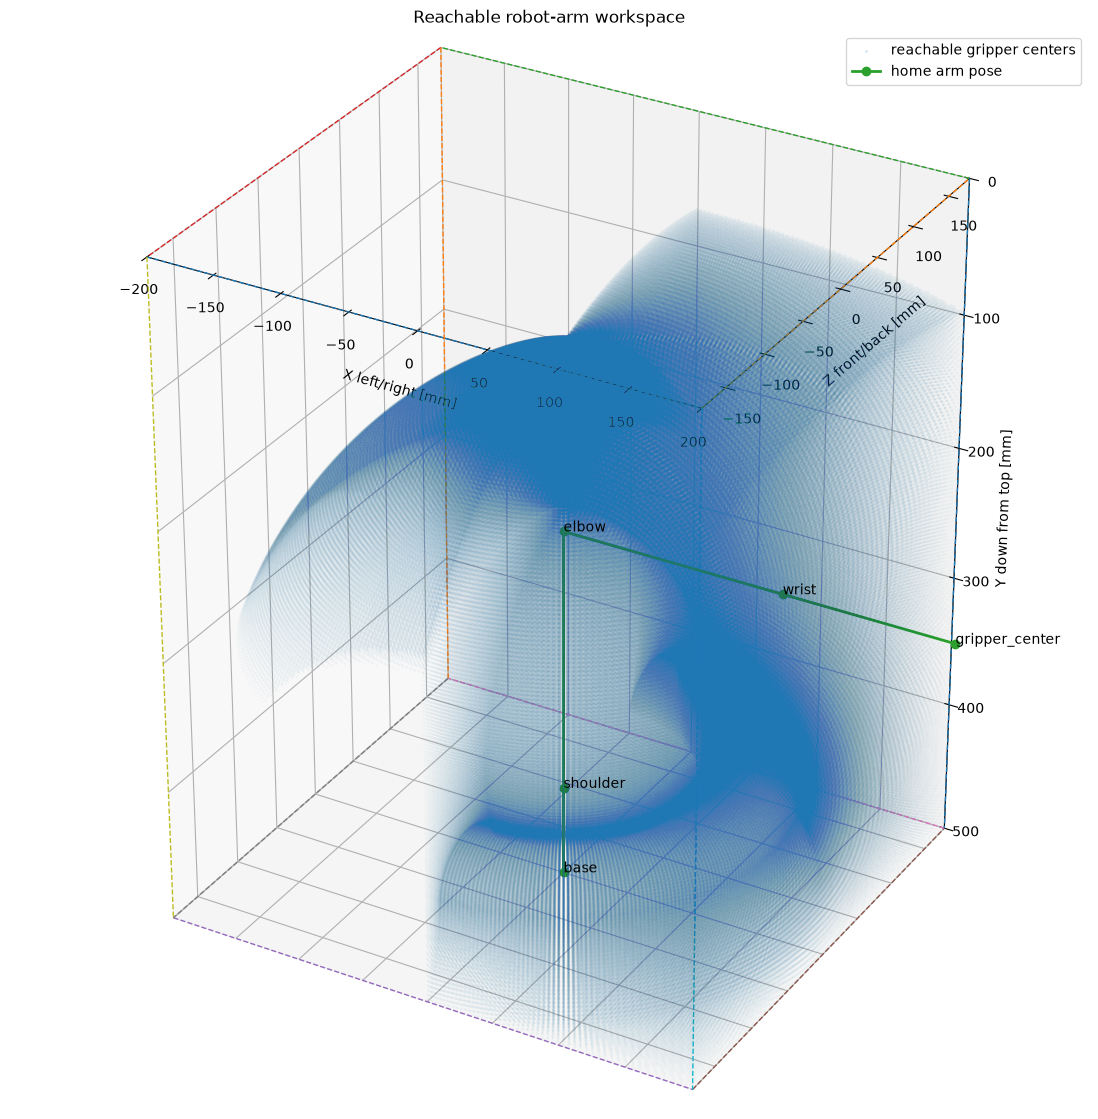

In [5]:
def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--angle-step-deg", type=float, default=1.0,
                        help="1.0 checks every integer degree in the configured limits.")
    parser.add_argument("--no-pose", action="store_true", help="Do not draw the configured home pose.")
    parser.add_argument("--save", type=Path, default=None, help="Optional image output path, for example workspace.png")
    args = parser.parse_known_args()[0] if "ipykernel" in sys.modules else parser.parse_args()

    cfg = load_robot_config()
    points = sample_reachable_gripper_points(cfg, args.angle_step_deg)
    if len(points) == 0:
        raise RuntimeError("No points were inside the configured workspace box.")

    print(f"base: ({cfg.base_x:.1f}, {cfg.base_y:.1f}, {cfg.base_z:.1f}) mm")
    print(f"shoulder: ({cfg.base_x:.1f}, {cfg.shoulder_y:.1f}, {cfg.base_z:.1f}) mm")
    print(f"points inside box: {len(points):,}")
    print("point ranges:")
    print(f"  X {points[:, 0].min():.1f} .. {points[:, 0].max():.1f} mm")
    print(f"  Y {points[:, 1].min():.1f} .. {points[:, 1].max():.1f} mm")
    print(f"  Z {points[:, 2].min():.1f} .. {points[:, 2].max():.1f} mm")

    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(*xyz_to_plot(points), s=1, alpha=0.15, label="reachable gripper centers")
    plot_workspace_box(ax, cfg)

    if not args.no_pose:
        pose = arm_points_from_angles(cfg, cfg.home_base, cfg.home_shoulder, cfg.home_elbow)
        plot_arm_pose(ax, pose)

    set_axis_limits(ax, cfg)
    ax.set_title("Reachable robot-arm workspace")
    ax.set_xlabel("X left/right [mm]")
    ax.set_ylabel("Z front/back [mm]")
    ax.set_zlabel("Y down from top [mm]")
    ax.legend(loc="upper right")

    if args.save is not None:
        fig.savefig(args.save, dpi=200, bbox_inches="tight")
        print("saved:", args.save)
    plt.show()


main()
